# Parrondo Weed-Control Experiment

This notebook compares weed-growth simulations under several management
strategies.

The first experiment establishes a baseline with:

- natural logistic growth;
- spatial spread between neighbouring cells;
- no weed-removal policy;
- 100 abstract simulation steps.

One simulation step represents one model update. No calendar-time interpretation
is assigned at this stage.

In [3]:
from pathlib import Path
import os

repo_root = Path.cwd().parents[0]
os.chdir(repo_root)

print(Path.cwd())

c:\Users\kazut\Documents\ChatGPT\cits4403_computational_model


In [7]:
import importlib

import matplotlib.pyplot as plt
import numpy as np

from src.data_loader import load_locality_data
import src.weed_ca

importlib.reload(src.weed_ca)

print("Imports completed")

Imports completed


## Load the spatial and population data

The source data contain locality polygons for Western Australia and Census
population data aggregated by postal area.

For this experiment, the Perth metropolitan study area is approximated using
postcodes from 6000 to 6199.

In [8]:
localities = load_locality_data()

metro = localities[
    localities["postcode"]
    .astype(int)
    .between(6000, 6199)
].copy()

print("All locality records:", len(localities))
print("Perth study-area records:", len(metro))
print(
    "Missing population-density values:",
    metro["population_density_km2"].isna().sum(),
)

All locality records: 1716
Perth study-area records: 375
Missing population-density values: 0


c:\Users\kazut\Documents\ChatGPT\cits4403_computational_model\src\data_loader.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  census["postcode"] = (


## Baseline configuration

The baseline uses fixed model parameters and does not apply a removal policy.

The population-pressure coefficient is set to `0.000783`. This value places the
median Perth population density near the midpoint of the initial weed-index
range.

The grid cell size is 1,000 metres. A smaller cell size may be evaluated later,
after the experiment framework has been validated.

The simulation runs for 100 abstract update steps.

In [9]:
PRESSURE_COEF = 0.000783
CELL_SIZE = 1000

GROWTH_RATE = 0.02
DIFFUSION_RATE = 0.01
CARRYING_CAPACITY = 1.0

STEPS = 100
HIGH_DENSITY_THRESHOLD = 0.7

print("Pressure coefficient:", PRESSURE_COEF)
print("Cell size:", CELL_SIZE, "metres")
print("Growth rate:", GROWTH_RATE)
print("Diffusion rate:", DIFFUSION_RATE)
print("Simulation steps:", STEPS)
print(
    "High-density threshold:",
    HIGH_DENSITY_THRESHOLD,
)

Pressure coefficient: 0.000783
Cell size: 1000 metres
Growth rate: 0.02
Diffusion rate: 0.01
Simulation steps: 100
High-density threshold: 0.7


## Model factory

Every experimental strategy must start from the same population data and model
parameters.

The `create_weedca()` function creates a new independent `WeedCA` instance for
each strategy. This avoids carrying state from one experiment into another.

In [10]:
def create_weedca():
    return src.weed_ca.WeedCA.polygon_to_weedca(
        metro,
        pressure_coef=PRESSURE_COEF,
        cell_size=CELL_SIZE,
        growth_rate=GROWTH_RATE,
        carrying_capacity=CARRYING_CAPACITY,
        diffusion_rate=DIFFUSION_RATE,
    )

In [11]:
initial_model = create_weedca()

print("Grid shape:", initial_model.weed_grid.shape)
print("Valid cells:", initial_model.valid_mask.sum())
print("Initial step:", initial_model.step_counter)
print("Initial cost:", initial_model.total_cost)

Grid shape: (203, 124)
Valid cells: 6933
Initial step: 0
Initial cost: 0


## Baseline simulation

The baseline represents uncontrolled weed growth.

Only the following processes are enabled:

1. logistic growth within each valid cell;
2. spread from higher-density neighbouring cells.

The removal process is disabled, so the cumulative management cost should
remain zero throughout the simulation.

In [12]:
baseline_weedca = create_weedca()

baseline_history, baseline_cost_history = (
    baseline_weedca.simulate(
        steps=STEPS,
        modes=["growth", "diffusion"],
    )
)

print("Baseline simulation completed")

Baseline simulation completed


## Validate the baseline output

The simulation history includes the initial state at step 0 followed by 100
updated states. Therefore, the history must contain 101 time points.

Because no removal policy is used, every value in the cost history should be
zero.

In [13]:
print("History shape:", baseline_history.shape)
print(
    "Cost-history shape:",
    baseline_cost_history.shape,
)

assert baseline_history.shape[0] == STEPS + 1
assert baseline_cost_history.shape[0] == STEPS + 1

assert baseline_history.shape[1:] == (
    baseline_weedca.weed_grid.shape
)

assert np.allclose(
    baseline_cost_history,
    0.0,
)

print("Baseline output validation passed")

History shape: (101, 203, 124)
Cost-history shape: (101,)
Baseline output validation passed


## Validate cells outside the study area

Cells outside the study area must remain `NaN` throughout the simulation.
These cells represent the sea or areas outside the rasterised Perth study area.

In [14]:
invalid_cells = ~baseline_weedca.valid_mask

invalid_history = baseline_history[
    :,
    invalid_cells,
]

assert np.all(
    np.isnan(invalid_history)
)

print(
    "Invalid cells remained NaN "
    "throughout the simulation"
)

Invalid cells remained NaN throughout the simulation


## Baseline metrics

Three metrics are calculated for every simulation step:

1. mean weed index across all valid cells;
2. number of high-density cells with a weed index of at least 0.7;
3. cumulative removal cost.

These metrics will later be calculated in the same way for Policy A, Policy B,
and the alternating A/B policy.

In [15]:
baseline_mean_weed = np.nanmean(
    baseline_history,
    axis=(1, 2),
)

print(
    "Initial mean weed index:",
    baseline_mean_weed[0],
)

print(
    "Final mean weed index:",
    baseline_mean_weed[-1],
)

Initial mean weed index: 0.86057454
Final mean weed index: 0.9814244


In [16]:
baseline_high_density_cells = np.sum(
    baseline_history >= HIGH_DENSITY_THRESHOLD,
    axis=(1, 2),
)

print(
    "Initial high-density cells:",
    baseline_high_density_cells[0],
)

print(
    "Final high-density cells:",
    baseline_high_density_cells[-1],
)

Initial high-density cells: 5512
Final high-density cells: 6933


In [17]:
baseline_initial_mean = baseline_mean_weed[0]
baseline_final_mean = baseline_mean_weed[-1]

baseline_relative_change = (
    baseline_final_mean
    - baseline_initial_mean
) / baseline_initial_mean

print(
    "Relative change in mean weed index:",
    f"{baseline_relative_change:.2%}",
)

Relative change in mean weed index: 14.04%


## Store the baseline result

The baseline result is stored in a dictionary. Later strategies will use the
same structure, allowing their metrics to be plotted and compared together.

In [18]:
results = {}

results["baseline"] = {
    "history": baseline_history,
    "mean_weed": baseline_mean_weed,
    "high_density_cells": (
        baseline_high_density_cells
    ),
    "cost_history": baseline_cost_history,
    "relative_change": (
        baseline_relative_change
    ),
}

print(results["baseline"].keys())

dict_keys(['history', 'mean_weed', 'high_density_cells', 'cost_history', 'relative_change'])


In [19]:
results

{'baseline': {'history': array([[[0.9985292 , 0.9985292 , 0.9985292 , ...,        nan,
                  nan,        nan],
          [       nan, 0.9985292 , 0.9985292 , ...,        nan,
                  nan,        nan],
          [       nan, 0.9985292 , 0.9985292 , ...,        nan,
                  nan,        nan],
          ...,
          [       nan,        nan,        nan, ...,        nan,
                  nan,        nan],
          [       nan,        nan,        nan, ...,        nan,
                  nan,        nan],
          [       nan,        nan,        nan, ...,        nan,
                  nan,        nan]],
  
         [[0.9985586 , 0.9985586 , 0.9985586 , ...,        nan,
                  nan,        nan],
          [       nan, 0.9985586 , 0.9985586 , ...,        nan,
                  nan,        nan],
          [       nan, 0.9985586 , 0.9985586 , ...,        nan,
                  nan,        nan],
          ...,
          [       nan,        nan,        n

## Baseline time-series results

The first plot shows how the mean weed index changes over the 100 simulation
steps.

The second plot shows how many cells have a weed index greater than or equal to
the high-density threshold.

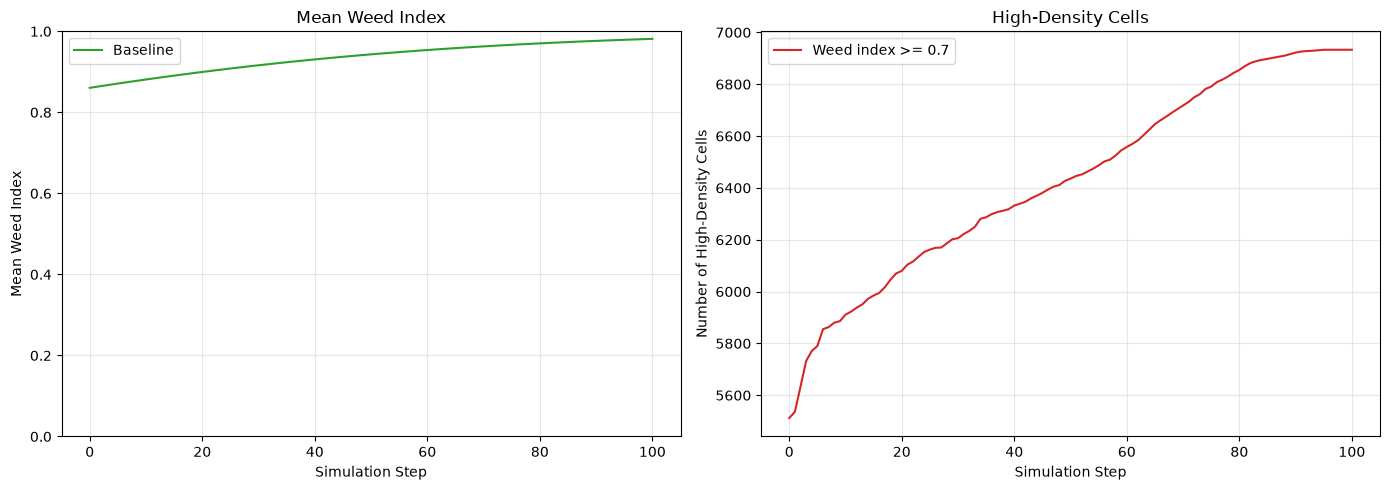

In [20]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

axes[0].plot(
    baseline_mean_weed,
    color="tab:green",
    label="Baseline",
)

axes[0].set_xlabel("Simulation Step")
axes[0].set_ylabel("Mean Weed Index")
axes[0].set_title("Mean Weed Index")
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    baseline_high_density_cells,
    color="tab:red",
    label=(
        f"Weed index >= "
        f"{HIGH_DENSITY_THRESHOLD}"
    ),
)

axes[1].set_xlabel("Simulation Step")
axes[1].set_ylabel(
    "Number of High-Density Cells"
)
axes[1].set_title("High-Density Cells")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Spatial baseline progression

The initial state and selected later steps are shown as raster maps.

All panels use the same colour scale so that changes between steps can be
compared directly.

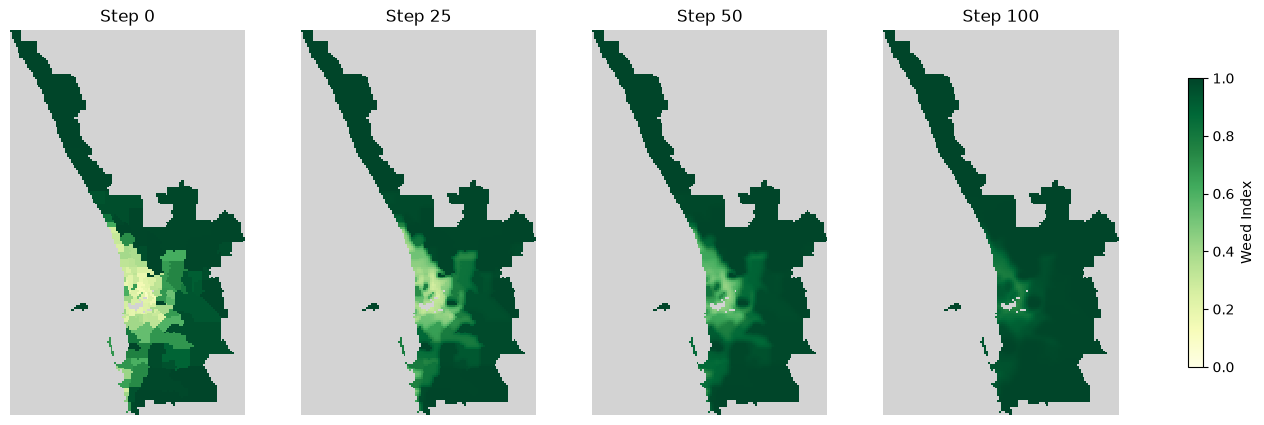

In [21]:
selected_steps = [0, 25, 50, 100]

fig, axes = plt.subplots(
    1,
    len(selected_steps),
    figsize=(18, 5),
)

cmap = plt.cm.YlGn.copy()
cmap.set_bad("lightgray")

for ax, step in zip(
    axes,
    selected_steps,
):
    image = ax.imshow(
        baseline_history[step],
        cmap=cmap,
        vmin=0,
        vmax=CARRYING_CAPACITY,
        interpolation="nearest",
    )

    ax.set_title(f"Step {step}")
    ax.axis("off")

fig.colorbar(
    image,
    ax=axes,
    label="Weed Index",
    shrink=0.75,
)

plt.show()

## Baseline summary

The baseline provides the uncontrolled reference trajectory for the weed model.

Expected behaviour:

- mean weed index increases over time;
- the number of high-density cells increases;
- cumulative removal cost remains zero;
- cells outside the study area remain invalid.

Policy A, Policy B, and the alternating A/B policy will be evaluated from the
same initial conditions and with the same model parameters.